In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load data same way as before
def load_arff_as_df(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    data_start = 0
    columns = []
    for i, line in enumerate(lines):
        if line.strip().upper().startswith('@ATTRIBUTE'):
            col_name = line.split()[1]
            columns.append(col_name)
        if line.strip().upper() == '@DATA':
            data_start = i + 1
            break
    data_lines = [l.strip() for l in lines[data_start:] 
                  if l.strip() and not l.startswith('%')]
    from io import StringIO
    csv_data = '\n'.join(data_lines)
    df = pd.read_csv(StringIO(csv_data), header=None, names=columns)
    return df

df = load_arff_as_df('KDDTrain+.arff')

# Convert text columns to numbers
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns[:-1]:
    df[col] = le.fit_transform(df[col])

print("Preprocessing done!")
print("Shape:", df.shape)

Preprocessing done! ✅
Shape: (125973, 42)


In [2]:
from sklearn.model_selection import train_test_split

# Last column is the label
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Ready to train!")

Train size: (100778, 41)
Test size: (25195, 41)
Ready to train!


In [3]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42
)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [4]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")
print("\nDetailed Results:")
print(classification_report(y_test, y_pred))

Accuracy: 99.87%

Detailed Results:
              precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00     11773
      normal       1.00      1.00      1.00     13422

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



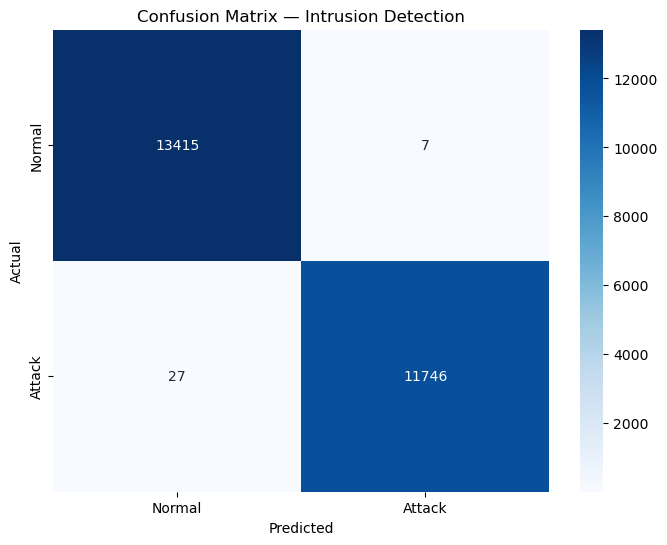

Confusion matrix saved!


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Binary: normal vs attack
y_test_binary = (y_test != 'normal').astype(int)
y_pred_binary = (y_pred != 'normal').astype(int)

cm = confusion_matrix(y_test_binary, y_pred_binary)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title('Confusion Matrix — Intrusion Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")

In [ ]:
import numpy as np

# Top 10 most important features
importance = model.feature_importances_
indices = np.argsort(importance)[-10:]

plt.figure(figsize=(10,6))
plt.barh(range(10), importance[indices], color='steelblue')
plt.yticks(range(10), [X.columns[i] for i in indices])
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("Feature importance saved!")